/Users/arthugt/Documents/sc/norton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


🚀 Iniciando o processo...
⏳ Baixando dataset do Kaggle (isso pode demorar dependendo da internet)...


100%|██████████| 202M/202M [10:50<00:00, 326kB/s] 

Extracting files...


✅ Dataset baixado em: /Users/arthugt/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1
📖 Lendo o arquivo /Users/arthugt/.cache/kagglehub/datasets/kartik2112/fraud-detection/versions/1/fraudTest.csv...
✅ Arquivo lido com sucesso! Total de linhas: 555719
✂️ Extraindo amostra de 10% (Passo 2)...
✅ Amostra criada com 55572 registros.
📏 Calculando distâncias geográficas (Haversine)...
✅ Cálculo finalizado em 0.03 segundos.
📊 Gerando gráfico Boxplot (Passo 3)...


/var/folders/4p/zw2plfkx5v59xyxbwbpbbrtw0000gn/T/ipykernel_2967/598024191.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='distancia_km', data=amostra, palette='Set2')


✅ Gráfico salvo como 'grafico_distancia.png'.


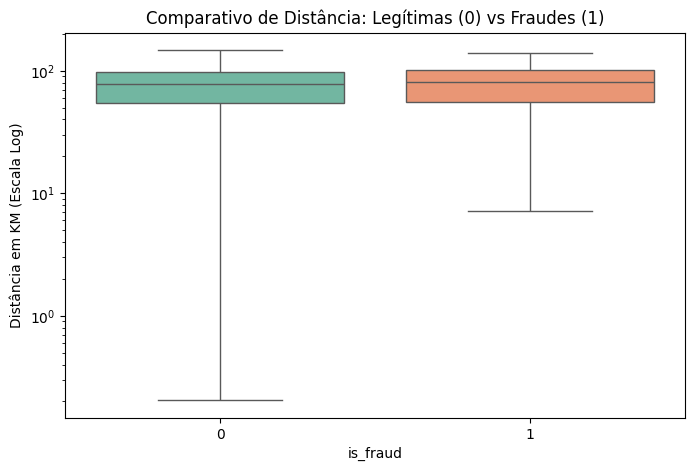


--- 📝 DADOS PARA O SEU ARTIGO NO OVERLEAF ---
            count       mean        std       min        25%        50%  \
is_fraud                                                                  
0         55356.0  75.846964  29.154291  0.205072  54.705007  77.965092   
1           216.0  78.310152  28.555601  7.100943  56.026039  81.039117   

                 75%         max  
is_fraud                          
0          98.386176  147.237488  
1         100.551671  139.995043  

🚀 Processo concluído com sucesso!


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

print("🚀 Iniciando o processo...")

# 1. DOWNLOAD DOS DADOS
print("⏳ Baixando dataset do Kaggle (isso pode demorar dependendo da internet)...")
path = kagglehub.dataset_download("kartik2112/fraud-detection")
print(f"✅ Dataset baixado em: {path}")

# 2. CARREGAMENTO
csv_path = os.path.join(path, "fraudTest.csv")
print(f"📖 Lendo o arquivo {csv_path}...")
df = pd.read_csv(csv_path)
print(f"✅ Arquivo lido com sucesso! Total de linhas: {len(df)}")

# 3. AMOSTRAGEM
print("✂️ Extraindo amostra de 10% (Passo 2)...")
amostra = df.sample(frac=0.1, random_state=42)
print(f"✅ Amostra criada com {len(amostra)} registros.")

# 4. CÁLCULO DE DISTÂNCIA
print("📏 Calculando distâncias geográficas (Haversine)...")
start_time = time.time()

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

amostra['distancia_km'] = haversine(amostra['lat'], amostra['long'], 
                                    amostra['merch_lat'], amostra['merch_long'])

end_time = time.time()
print(f"✅ Cálculo finalizado em {end_time - start_time:.2f} segundos.")

# 5. GRÁFICO
print("📊 Gerando gráfico Boxplot (Passo 3)...")
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_fraud', y='distancia_km', data=amostra, palette='Set2')
plt.yscale('log')
plt.title('Comparativo de Distância: Legítimas (0) vs Fraudes (1)')
plt.ylabel('Distância em KM (Escala Log)')
plt.savefig('grafico_distancia.png', dpi=300)
print("✅ Gráfico salvo como 'grafico_distancia.png'.")
plt.show()

# 6. RESUMO FINAL
print("\n--- 📝 DADOS PARA O OVERLEAF ---")
resumo = amostra.groupby('is_fraud')['distancia_km'].describe()
print(resumo)
print("\n🚀 Processo concluído com sucesso!")